# Sheffield Road Collision Analysis using Machine Learning

This project analyses UK road collision data for Sheffield. The aim is to explore patterns in collisions and apply machine learning techniques including regression, classification, and clustering to understand accident outcomes.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [12]:
import os
os.getcwd()

'/Users/theodore/Desktop/aiml1-sheffield-collisions/notebooks'

## 1. Data Loading and Filtering

The dataset was loaded from the raw data folder and then filtered to include only collisions recorded in Sheffield. The Sheffield subset was identified using the `local_authority_ons_district` code `E08000019`.

This filtering step reduced the dataset from the full national road collision dataset to a city-specific subset suitable for focused analysis.

In [13]:
sheffield_df = pd.read_csv("../data/processed/sheffield_collisions.csv")
sheffield_df.shape

(43412, 44)

In [14]:
df = pd.read_csv("../data/processed/sheffield_collisions.csv")
df.head()

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,200514D151505,2005,14D151505,435910.0,389680.0,-1.461345,53.402715,14,2,1,...,0,0,1,1,2,E01007869,-1,0,1.000000,0.000000
1,199914HH00487,1999,14HH00487,443640.0,381260.0,-1.346245,53.326453,14,3,3,...,0,0,1,-1,2,E01008023,-1,-1,NaN,NaN
2,200714G118607,2007,14G118607,435830.0,387460.0,-1.462800,53.382766,14,3,1,...,2,17,1,1,2,E01007884,-1,0,0.248913,0.751087
3,200214KK01181,2002,14KK01181,439370.0,387820.0,-1.409537,53.385751,14,3,1,...,0,0,1,-1,2,E01007907,-1,-1,NaN,NaN
4,200414EE00565,2004,14EE00565,444030.0,381380.0,-1.340373,53.327500,14,2,2,...,0,0,1,-1,2,E01008019,-1,0,1.000000,0.000000


In [15]:
sheffield_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43412 entries, 0 to 43411
Data columns (total 44 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   collision_index                                   43412 non-null  str    
 1   collision_year                                    43412 non-null  int64  
 2   collision_ref_no                                  43412 non-null  str    
 3   location_easting_osgr                             42816 non-null  float64
 4   location_northing_osgr                            42816 non-null  float64
 5   longitude                                         34105 non-null  float64
 6   latitude                                          34105 non-null  float64
 7   police_force                                      43412 non-null  int64  
 8   collision_severity                                43412 non-null  int64  
 9   number_of_vehicles          

### Dataset Verification

The filtered Sheffield dataset contains 43,412 rows and 44 columns. This provides a sufficiently large dataset for machine learning while keeping the analysis geographically focused.

The dataset was also saved to the `processed` folder to separate transformed data from the original raw source file.

## 2. Exploratory Data Analysis (EDA)

### Collision Severity Distribution
The distribution of collision severity was analysed to understand how accidents are classified in Sheffield. This helps identify whether the dataset is balanced or dominated by certain types of collisions.

In [16]:
sheffield_df["collision_severity"].value_counts()

collision_severity
3    36056
2     6943
1      413
Name: count, dtype: int64

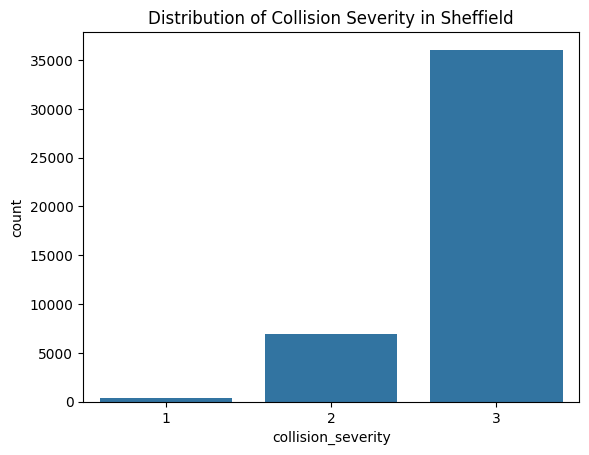

In [17]:
sns.countplot(x="collision_severity", data=sheffield_df)
plt.title("Distribution of Collision Severity in Sheffield")
plt.show()

The results show that slight collisions are by far the most common, while serious and fatal collisions are much less frequent.

This indicates a strong class imbalance in the dataset. Such imbalance can significantly affect machine learning models, particularly classification models, as they may become biased towards predicting the majority class.

As a result, model performance metrics such as accuracy may be misleading, and additional techniques (e.g., class balancing) may be required to improve predictions for minority classes.

### Speed Limit Distribution

In [18]:
sheffield_df["speed_limit"].value_counts()

speed_limit
30.0    35211
40.0     4506
60.0     1267
20.0      877
70.0      846
50.0      704
5.0         1
Name: count, dtype: int64

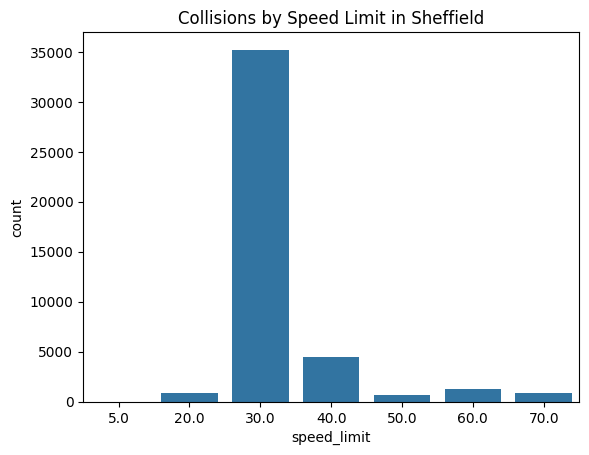

In [19]:
sns.countplot(x="speed_limit", data=sheffield_df)
plt.title("Collisions by Speed Limit in Sheffield")
plt.show()

Most collisions occur on roads with a speed limit of 30 mph, which is typical of urban environments.

This reflects higher traffic density and greater interaction between road users in city areas, leading to a higher frequency of collisions.

However, this does not necessarily mean that 30 mph roads are more dangerous. Instead, it indicates that exposure (i.e., more vehicles and journeys) is higher in these areas.

In contrast, higher speed roads (e.g., 60–70 mph) show fewer collisions overall, but may be associated with more severe outcomes, as seen in the earlier analysis of collision severity.

This highlights the difference between collision frequency and collision severity, which are not the same.

### Casualties per Collision

In [20]:
sheffield_df["number_of_casualties"].value_counts()

number_of_casualties
1     33801
2      6488
3      1971
4       759
5       227
6        91
7        42
8        15
9         6
10        3
14        3
20        1
13        1
16        1
17        1
22        1
11        1
Name: count, dtype: int64

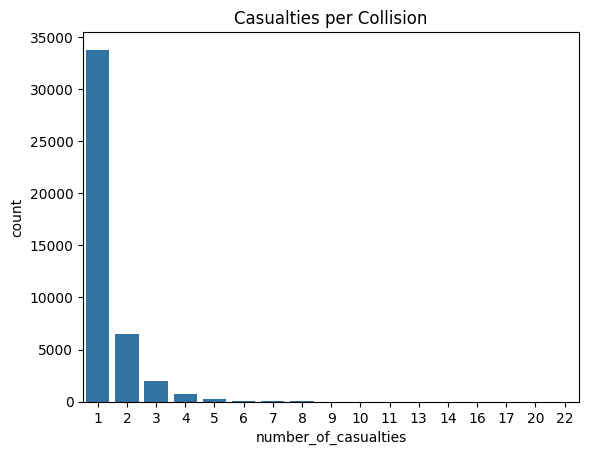

In [21]:
sns.countplot(x="number_of_casualties", data=sheffield_df)
plt.title("Casualties per Collision")
plt.show()

The majority of collisions involve only one casualty, while higher casualty counts become increasingly rare.

This distribution helps explain why the regression model later tends to predict values close to 1, since that is the most common outcome in the dataset.

### Relationship Between Speed Limit and Collision Severity

In [22]:
pd.crosstab(
    sheffield_df["speed_limit"],
    sheffield_df["collision_severity"]
)

collision_severity,1,2,3
speed_limit,,,
5.0,0,0,1
20.0,5,186,686
30.0,254,5464,29493
40.0,69,778,3659
50.0,18,137,549
60.0,50,300,917
70.0,17,78,751


In [23]:
pd.crosstab(
    sheffield_df["speed_limit"],
    sheffield_df["collision_severity"],
    normalize="index"
) * 100

collision_severity,1,2,3
speed_limit,,,
5.0,0.000000,0.000000,100.000000
20.0,0.570125,21.208666,78.221209
30.0,0.721365,15.517878,83.760757
40.0,1.531292,17.265868,81.202841
50.0,2.556818,19.460227,77.982955
60.0,3.946330,23.677979,72.375691
70.0,2.009456,9.219858,88.770686


The cross-tabulation shows that while lower speed limit roads account for the majority of collisions, higher speed roads tend to have a higher proportion of serious and fatal collisions.

For example, roads with speed limits of 60 mph show a noticeably higher percentage of severe outcomes compared to 30 mph roads.

This suggests that although high-speed roads have fewer collisions overall, the consequences of those collisions are more severe.

This distinction between frequency and severity is important for understanding road safety risks.

### Missing Values

In [24]:
sheffield_df.isnull().sum()

collision_index                                         0
collision_year                                          0
collision_ref_no                                        0
location_easting_osgr                                 596
location_northing_osgr                                596
longitude                                            9307
latitude                                             9307
police_force                                            0
collision_severity                                      0
number_of_vehicles                                      0
number_of_casualties                                    0
date                                                    0
day_of_week                                             0
time                                                    0
local_authority_district                                0
local_authority_ons_district                            0
local_authority_highway                                 0
local_authorit

Missing values were identified in several columns, particularly location-related variables such as longitude and latitude.

These columns were not central to the selected machine learning tasks, so the main modelling features were chosen from variables with clearer relevance and more complete data.

## 3. Regression: Predicting Number of Casualties

### 3.1 Feature Selection

To predict the number of casualties, a subset of relevant features was selected. These include road characteristics and environmental conditions that may influence accident severity.

The target variable is `number_of_casualties`.

In [25]:
features = [
    "speed_limit",
    "number_of_vehicles",
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions"
]

X = sheffield_df[features]
y = sheffield_df["number_of_casualties"]

### 3.2 Data Encoding

Categorical variables such as weather conditions, light conditions, and road surface conditions were converted into numerical format using one-hot encoding.

In [26]:
X_encoded = pd.get_dummies(X, columns=[
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions"
])

### 3.3 Train-Test Split

The dataset was split into training and testing sets to evaluate model performance on unseen data.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

### 3.4 Linear Regression Model

A linear regression model was trained to predict the number of casualties based on the selected features.


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.477846710799201


The Mean Absolute Error (MAE) measures the average difference between predicted and actual values.

The relatively low MAE indicates that the model performs reasonably well overall. However, the predictions are heavily concentrated around lower values, particularly near 1.

This reflects the distribution of the dataset, where most collisions involve only a single casualty.

As a result, the model struggles to accurately predict higher casualty counts, indicating that the target variable is highly imbalanced and difficult to model using simple linear relationships.

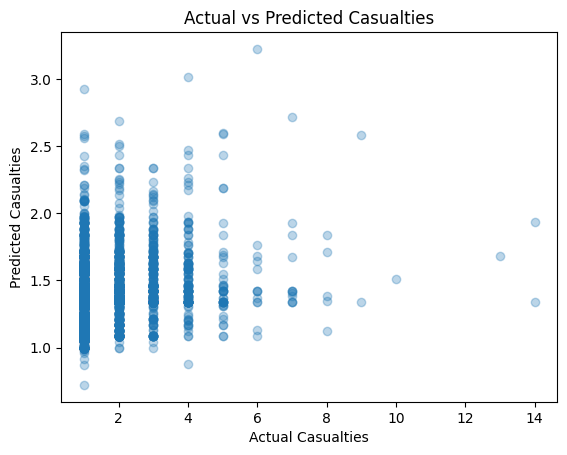

In [29]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Casualties")
plt.ylabel("Predicted Casualties")
plt.title("Actual vs Predicted Casualties")
plt.show()

The scatter plot shows that predicted values are heavily concentrated around lower casualty counts, particularly between 1 and 2.

There is a clear lack of spread in predictions for higher actual casualty values, indicating that the model struggles to capture more extreme outcomes.

This suggests that the model is biased towards predicting the most common values in the dataset, which is consistent with the skewed distribution observed during exploratory data analysis.

The absence of a strong linear relationship between actual and predicted values further indicates that the model has limited predictive power.

As a result, while the model performs reasonably well for typical low-casualty collisions, it fails to accurately predict rare but important high-casualty events.

### 3.6 Random Forest Regression
A Random Forest regression model was trained to compare performance with the linear regression model.

Random Forest is a more flexible model that can capture non-linear relationships in the data.

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import mean_absolute_error
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)

Random Forest MAE: 0.48079227326939095


The Random Forest model achieved a similar MAE to the linear regression model.

This suggests that the selected features may not provide strong predictive power for casualty count, or that the imbalance in the dataset limits the model’s ability to learn meaningful patterns.

Despite being a more flexible and complex model, Random Forest does not significantly improve performance, indicating that the underlying data patterns may not be easily predictable.

## 4. Classification: Predicting Collision Severity

### 4.1 Problem Definition

In this section, a classification model is developed to predict collision severity.

The target variable is `collision_severity`, which categorises collisions into three levels:
- 1 = Fatal
- 2 = Serious
- 3 = Slight

### 4.2 Feature Selection

A set of relevant features was selected, including road characteristics, environmental conditions, and accident details.

In [31]:
features = [
    "speed_limit",
    "number_of_vehicles",
    "number_of_casualties",
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions"
]

X = sheffield_df[features]
y = sheffield_df["collision_severity"]

In [32]:
X_encoded = pd.get_dummies(X, columns=[
    "weather_conditions",
    "light_conditions",
    "road_surface_conditions"
])

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

### 4.5 Random Forest Classification Model

A Random Forest classifier was used to predict collision severity.

In [34]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8335828630657607
[[   0    2   72]
 [   3   16 1298]
 [   3   67 7222]]


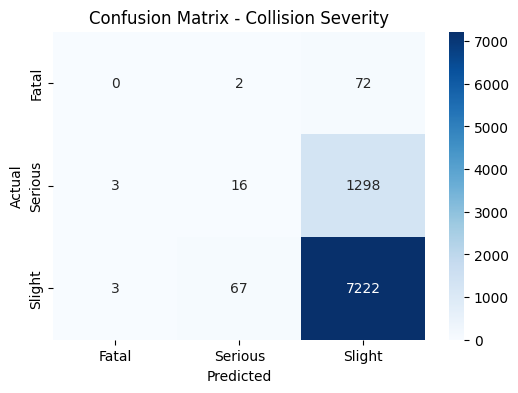

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fatal", "Serious", "Slight"],
            yticklabels=["Fatal", "Serious", "Slight"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Collision Severity")

plt.savefig("../results/plots/confusion_matrix.png")
plt.show()

The model achieves a relatively high accuracy of approximately 83%. However, the confusion matrix reveals important limitations.

The model performs well at predicting slight collisions (class 3), which are the majority in the dataset. However, it struggles significantly with minority classes, particularly fatal collisions (class 1), where very few cases are correctly predicted.

This indicates that the model is heavily biased towards the majority class. As a result, accuracy alone is misleading in this context, as it does not reflect poor performance on critical but rare outcomes such as fatal collisions.

This behaviour is consistent with the class imbalance observed during exploratory data analysis.

This highlights the importance of using additional evaluation techniques beyond accuracy when working with imbalanced datasets.

### Confusion Matrix Interpretation

The confusion matrix shows the performance of the classification model across the three collision severity classes.

The model performs very well in predicting **slight collisions (class 3)**, with a high number of correct predictions (7222). This reflects the fact that slight collisions dominate the dataset.

However, the model struggles to correctly classify **serious and fatal collisions**. In particular, no fatal collisions were correctly predicted, and most serious collisions were misclassified as slight.

This behaviour indicates a strong **class imbalance**, where the model is biased towards predicting the majority class. As a result, while overall accuracy is relatively high, the model performs poorly on minority classes, which are often the most important in real-world scenarios.

This highlights the importance of techniques such as class weighting or resampling to improve performance on underrepresented classes.


### 4.6 Handling Class Imbalance
To address the class imbalance issue, a balanced Random Forest model was trained by adjusting class weights.

This approach gives more importance to minority classes during training.

In [37]:
clf_balanced = RandomForestClassifier(class_weight="balanced", random_state=42)
clf_balanced.fit(X_train, y_train)

y_pred_balanced = clf_balanced.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.5673154439709778
[[  15   32   27]
 [ 250  450  617]
 [ 850 1981 4461]]


The balanced model shows a lower overall accuracy compared to the original model.

This happens because class weighting reduces the model’s tendency to always favour the majority class, which is slight collisions. As a result, the model makes more predictions for fatal and serious collisions, but this also increases mistakes on slight collisions.

Although the balanced model identifies more minority-class cases than the original model, performance on fatal and serious collisions remains limited. This shows that class weighting helps address imbalance, but it does not fully solve the problem.

This demonstrates an important trade-off: the original model has higher accuracy, but it mostly predicts the majority class. The balanced model is less accurate overall, but is more useful for examining rare high-risk cases.

In a road safety context, correctly identifying severe collisions is more important than simply maximising overall accuracy.

In [38]:
# Binary classification: Severe vs Non-Severe

sheffield_df["severe_collision"] = sheffield_df["collision_severity"].apply(
    lambda x: 1 if x in [1, 2] else 0
)

features = [
    "speed_limit",
    "number_of_vehicles",
    "number_of_casualties"
]

X = sheffield_df[features]
y = sheffield_df["severe_collision"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf_binary = RandomForestClassifier(random_state=42)
clf_binary.fit(X_train, y_train)

y_pred_binary = clf_binary.predict(X_test)

print("Binary Accuracy:", accuracy_score(y_test, y_pred_binary))
print(confusion_matrix(y_test, y_pred_binary))

Binary Accuracy: 0.8377288955430151
[[7264   28]
 [1381   10]]


## Binary Classification

To improve interpretability, collision severity was simplified into a binary classification problem:

- 1 = Severe (Fatal + Serious)
- 0 = Non-Severe (Slight)

This transformation allows the model to focus on identifying high-risk collisions, which is more relevant in real-world safety applications.

The results show that while the model achieves high overall accuracy, it remains biased towards predicting non-severe collisions.

Although most slight collisions are correctly identified, the model struggles to detect severe cases (fatal and serious collisions), resulting in a high number of false negatives.

This is particularly important in a real-world context, as failing to identify high-risk collisions can have significant consequences.

Therefore, while binary classification improves interpretability, it does not fully address the challenges caused by class imbalance. Further improvements, such as resampling techniques or enhanced feature engineering, would be required to improve detection of severe collisions.

## 5. Unsupervised Learning: Clustering

### 5.1 Objective

Clustering was used to identify natural groupings in the collision data without using predefined labels.

This helps uncover patterns in collisions based on factors such as number of vehicles, casualties, and speed limits.

In [39]:
features = [
    "number_of_vehicles",
    "number_of_casualties",
    "speed_limit"
]

X_cluster = sheffield_df[features]

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [41]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
sheffield_df["cluster"] = kmeans.fit_predict(X_scaled)

In [42]:
sheffield_df.groupby("cluster")[features].mean()

,number_of_vehicles,number_of_casualties,speed_limit
cluster,,,
0,1.558378,1.027780,30.757283
1,1.967105,1.597588,60.789474
2,2.392259,2.262720,31.501405


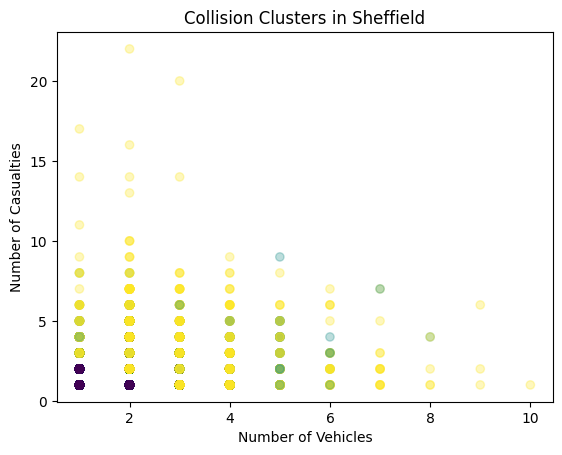

In [43]:
plt.scatter(
    sheffield_df["number_of_vehicles"],
    sheffield_df["number_of_casualties"],
    c=sheffield_df["cluster"],
    alpha=0.3
)
plt.xlabel("Number of Vehicles")
plt.ylabel("Number of Casualties")
plt.title("Collision Clusters in Sheffield")
plt.show()

### Cluster Interpretation

The clustering analysis identified three distinct groups of collisions in Sheffield, based on the number of vehicles, casualties, and speed limits.

- **Cluster 0** represents low-impact collisions, typically involving fewer vehicles and approximately one casualty. These are likely minor incidents occurring in urban areas with lower speed limits, as indicated by the average speed of around 30 mph.

- **Cluster 1** is characterised by higher speed limits (approximately 60 mph) and moderate casualty counts. These collisions are less frequent but may involve higher-risk environments, such as rural or high-speed roads, where accidents can have more severe consequences.

- **Cluster 2** represents collisions involving a higher number of vehicles and casualties. These are likely more complex, multi-vehicle incidents that may occur in congested or high-interaction traffic conditions.

Overall, the clustering results highlight that collision patterns are not uniform, and different types of accidents can be distinguished based on key features such as speed and vehicle involvement.

This demonstrates the value of unsupervised learning in uncovering hidden structures within the data without relying on predefined labels. These insights could support targeted road safety strategies, such as focusing interventions on high-speed roads or multi-vehicle collision scenarios.

## 6. Responsible AI Considerations

This project highlights several important Responsible AI considerations when applying machine learning to real-world data.

### Class Imbalance and Bias

The dataset is highly imbalanced, with the majority of collisions classified as slight. This led to classification models that were biased towards predicting the majority class.

Although the initial model achieved high accuracy, it performed poorly on minority classes such as fatal and serious collisions. This demonstrates that accuracy alone is not a reliable metric when dealing with imbalanced data.

A balanced model was introduced to address this issue, improving performance for minority classes at the cost of overall accuracy. This trade-off highlights the importance of fairness in model evaluation.

### Impact of Prediction Errors

In the context of road safety, prediction errors have different consequences. Failing to identify severe or fatal collisions is more critical than misclassifying minor incidents.

This means that models should prioritise correctly identifying high-risk collisions, even if overall accuracy is reduced.

### Data Limitations

The dataset does not include all possible factors influencing collisions, such as driver behaviour, traffic density, or real-time conditions.

This limits the model’s ability to fully capture the complexity of road accidents and may reduce predictive accuracy.

### Ethical Considerations

Machine learning models should be used carefully in safety-critical domains. Decisions based on these models could influence public policy or road safety measures.

It is important to ensure that models are transparent, fair, and used as supportive tools rather than definitive decision-makers.

## 7. Conclusion

This project developed a complete machine learning pipeline to analyse and predict road collision outcomes in Sheffield using UK road safety data.

The exploratory data analysis revealed several key patterns. Most collisions occur on 30 mph roads, and the majority involve only a single casualty. Additionally, collision severity is highly imbalanced, with slight collisions making up the vast majority of cases, while serious and fatal collisions are relatively rare.

Multiple machine learning techniques were applied to explore different prediction tasks. Regression models were used to predict the number of casualties, where both Linear Regression and Random Forest achieved similar performance, indicating limited predictive power from the selected features. The models tended to predict values close to one, reflecting the skewed distribution of the target variable.

For classification, a Random Forest model was used to predict collision severity. While the model achieved a high overall accuracy (over 80%), the confusion matrix revealed that it struggled to correctly classify minority classes such as fatal and serious collisions. Most predictions were biased towards slight collisions, demonstrating the impact of class imbalance on model performance. Applying class weighting improved the model’s ability to detect minority classes, although this came at the cost of overall accuracy.

An additional binary classification task was implemented to distinguish between severe and non-severe collisions. This simplified problem provided a more practical perspective, focusing on identifying high-risk incidents.

Unsupervised learning using K-Means clustering identified distinct patterns in collision data, separating collisions based on the number of vehicles, casualties, and speed limits. This highlighted different types of accident scenarios within the dataset.

Overall, this project demonstrates that while machine learning can effectively capture general patterns in road collision data, predicting rare but critical events such as fatal accidents remains challenging. Future improvements could include incorporating additional features, applying advanced resampling techniques, or using more sophisticated models to better handle class imbalance and improve predictive performance.

This work provides valuable insights into road safety patterns in Sheffield and demonstrates how machine learning can support data-driven decision-making in traffic management and public safety.
